# 🚗 Car Price Prediction using Machine Learning

## Project Overview

This project aims to predict the selling price of used cars using Machine Learning. The model is trained on historical car data containing information such as manufacturing year, present price, fuel type, transmission type, seller type, ownership, and kilometers driven.

## Step 1: Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Step 2: Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv("car data.csv")

# Display the first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Step 3: Understand the Dataset

In [ ]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (301, 9)

Column Names:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


## Step 4: Check Missing Values and Statistical Summary

In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Display statistical summary
print("\nStatistical Summary:")
df.describe()

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Statistical Summary:


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


##  Step 5: Exploratory Data Analysis : Analyzing the data visually and statistically to understand patterns, relationships, and anomalies before building a machine learning model.

## Step 5.1: Correlation Heatmap

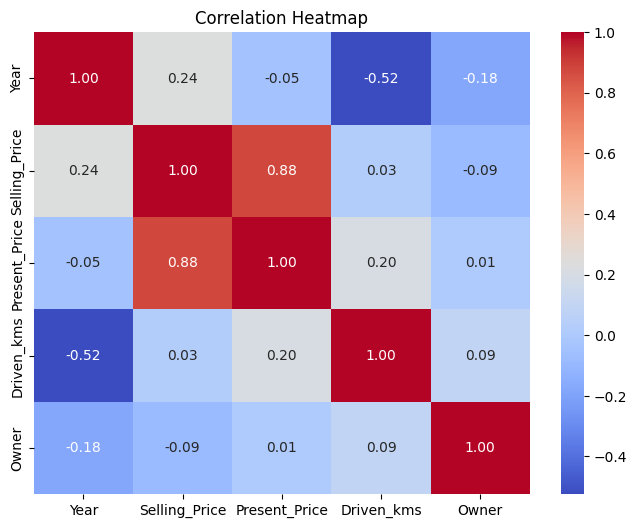

In [5]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Create correlation matrix
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

## Step 5.2: Analyze Categorical Features

In [7]:
# Display unique values in categorical columns

categorical_columns = ["Fuel_Type", "Selling_type", "Transmission"]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


Fuel_Type:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Selling_type:
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


## Step 5.3: Visualize Categorical Features

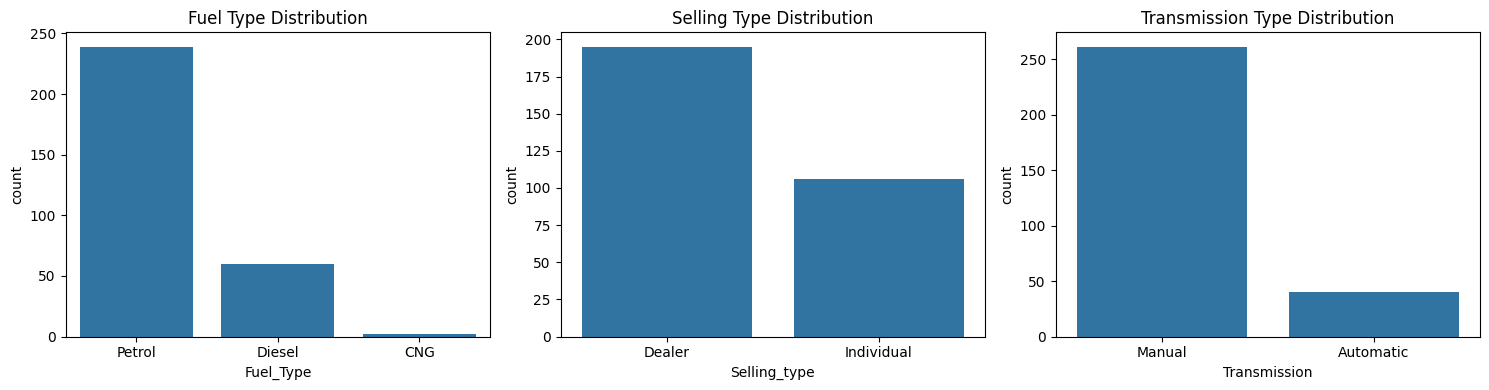

In [8]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.countplot(x="Fuel_Type", data=df)
plt.title("Fuel Type Distribution")

plt.subplot(1,3,2)
sns.countplot(x="Selling_type", data=df)
plt.title("Selling Type Distribution")

plt.subplot(1,3,3)
sns.countplot(x="Transmission", data=df)
plt.title("Transmission Type Distribution")

plt.tight_layout()
plt.show()

## Step 5.4: Detect Outliers Using Box Plots

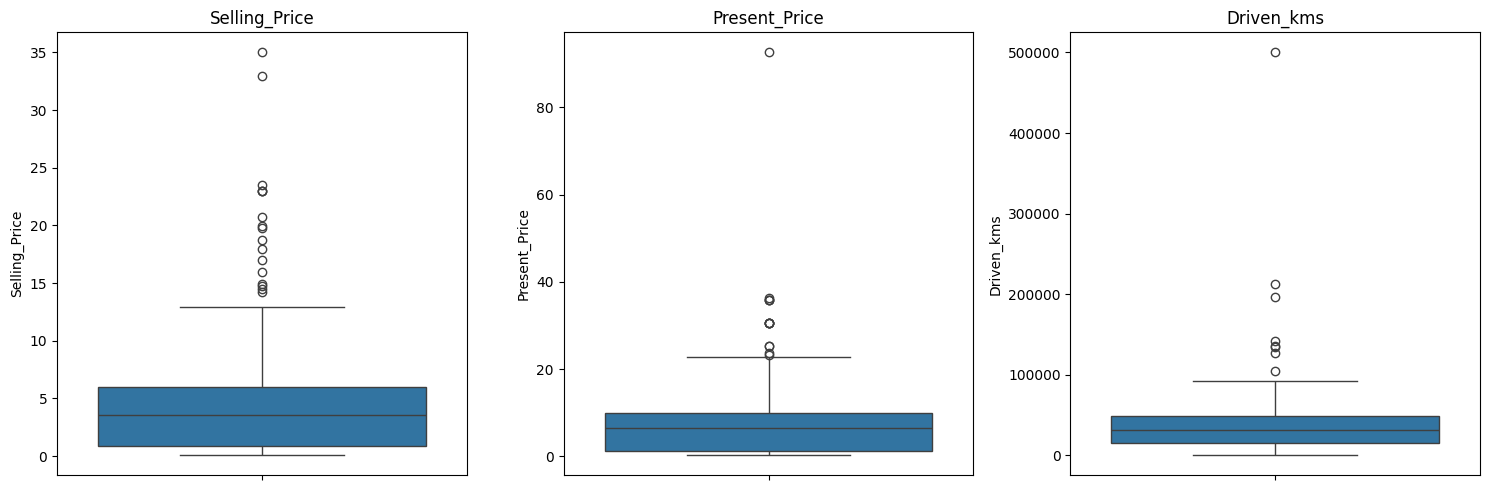

In [9]:
# Numerical columns
numerical_columns = [
    "Selling_Price",
    "Present_Price",
    "Driven_kms"
]

plt.figure(figsize=(15,5))

for i, column in enumerate(numerical_columns):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

## Step 5.5: Distribution of Selling Price

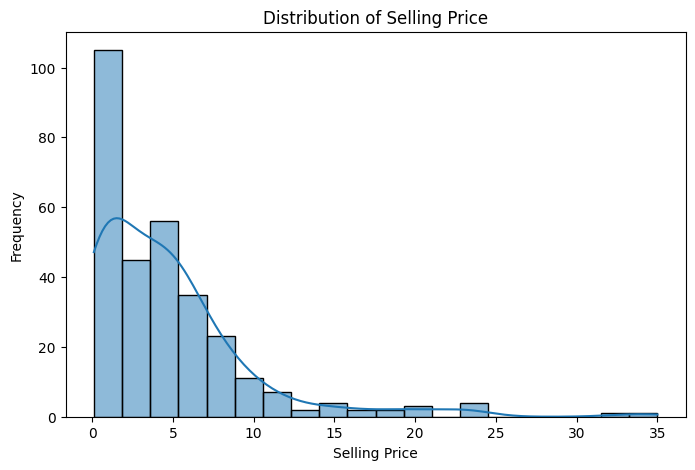

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], bins=20, kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

## Step 6: Feature Engineering

In [11]:
# Create a new feature: Car Age
df["Car_Age"] = 2025 - df["Year"]

# Display first few rows
df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,11
1,2013,12
2,2017,8
3,2011,14
4,2014,11


## Step 7: Drop Unnecessary Columns

In [12]:
# Drop unnecessary columns
df.drop(["Car_Name", "Year"], axis=1, inplace=True)

# Display updated dataset
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


## Step 8: Encode Categorical Variables

In [13]:
# Convert categorical variables into numerical variables
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

# Display the first 5 rows
df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


## Step 9: Separate Features and Target Variable

In [14]:
# Features (Independent Variables)
X = df.drop("Selling_Price", axis=1)

# Target (Dependent Variable)
y = df["Selling_Price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (301, 8)
Target Shape: (301,)


## Step 10: Split Dataset into Training and Testing Sets

In [15]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (240, 8)
Testing Features: (61, 8)
Training Target: (240,)
Testing Target: (61,)


## Step 11: Train Linear Regression Model

In [16]:
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## Step 12: Predict Selling Prices

In [17]:
# Predict selling prices
y_pred_lr = lr_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred_lr[:10])

First 10 Predictions:
[ 2.95433731  8.17716341  6.45612271 -1.42337164  9.08864657  7.41793553
  1.33513921  0.84032259  1.36320242  7.49067757]


## Step 13: Evaluate Linear Regression Model

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-" * 35)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Linear Regression Performance
-----------------------------------
Mean Absolute Error (MAE): 1.22
Mean Squared Error (MSE): 3.48
Root Mean Squared Error (RMSE): 1.87
R² Score: 0.8489


## Step 14: Train Decision Tree Regressor

In [19]:
from sklearn.tree import DecisionTreeRegressor

# Create the model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Regressor trained successfully!")

Decision Tree Regressor trained successfully!


## Step 15: Evaluate Decision Tree Regressor

In [20]:
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-" * 35)
print(f"MAE : {dt_mae:.2f}")
print(f"RMSE: {dt_rmse:.2f}")
print(f"R² Score: {dt_r2:.4f}")

Decision Tree Performance
-----------------------------------
MAE : 0.73
RMSE: 1.12
R² Score: 0.9455


## Step 16: Train Random Forest Regressor

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


## Step 17: Evaluate Random Forest Regressor

In [22]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-" * 35)
print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")

Random Forest Performance
-----------------------------------
MAE : 0.65
RMSE: 0.98
R² Score: 0.9585


## Step 18: Compare Model Performance

In [23]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse
    ],
    "R² Score": [
        r2,
        dt_r2,
        rf_r2
    ]
})

results = results.sort_values(
    by="R² Score",
    ascending=False
)

results

,Model,MAE,RMSE,R² Score
2,Random Forest,0.649421,0.977369,0.958532
1,Decision Tree,0.733443,1.120697,0.945477
0,Linear Regression,1.216374,1.865838,0.848871


## Step 19: Feature Importance Analysis

In [24]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Present_Price,0.879515
3,Car_Age,0.061085
1,Driven_kms,0.040046
7,Transmission_Manual,0.009704
5,Fuel_Type_Petrol,0.003450
4,Fuel_Type_Diesel,0.003398
6,Selling_type_Individual,0.002316
2,Owner,0.000486


## Step 20: Predict Selling Price for a New Car

In [25]:
# Create a sample with all feature columns initialized to 0
sample = pd.DataFrame(0, index=[0], columns=X.columns)

# Fill in values
sample["Present_Price"] = 8.50
sample["Driven_kms"] = 45000
sample["Owner"] = 0
sample["Car_Age"] = 5

# Set encoded categorical values (adjust based on your X.columns)
if "Fuel_Type_Petrol" in sample.columns:
    sample["Fuel_Type_Petrol"] = 1

if "Selling_type_Individual" in sample.columns:
    sample["Selling_type_Individual"] = 1

if "Transmission_Manual" in sample.columns:
    sample["Transmission_Manual"] = 1

predicted_price = rf_model.predict(sample)

print(f"Predicted Selling Price: ₹ {predicted_price[0]:.2f} Lakhs")

Predicted Selling Price: ₹ 6.64 Lakhs


# Conclusion

# Conclusion

This project successfully developed a machine learning model capable of predicting the selling price of used cars based on their features.

The project followed a complete machine learning workflow including:

- Data Exploration
- Exploratory Data Analysis
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Feature Importance Analysis
- Prediction on New Data

Multiple regression models were trained and compared. The best-performing model was selected based on evaluation metrics such as MAE, RMSE, and R² Score.

The project demonstrates the practical application of regression techniques in solving real-world price prediction problems.

## Step 22: Actual vs Predicted Selling Price

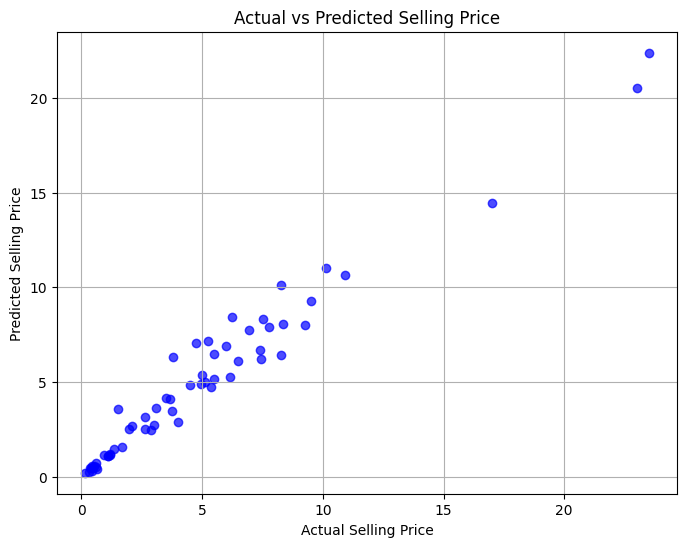

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf, color="blue", alpha=0.7)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.grid(True)

plt.show()

## Step 23: Save the Trained Model

In [28]:
import joblib

# Save the trained model
joblib.dump(rf_model, "car_price_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
